# Target-tenor skew diagnostics

Build the screened, arbitrage-aware Raw SVI surface for the current SPX quote date, apply the calendar repair, and extract 30D, 60D, and 90D smiles. ATM IV, the local ATM slope, and 25-delta risk reversal have independent support and quality flags. Failed metrics remain missing while available smiles stay visible for inspection.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.raw_svi import fit_raw_svi_surface
from src.skew_metrics import calculate_skew_metrics
from src.vol_surface import build_total_variance_grid, enforce_calendar_monotonicity

PANEL_PATH = ROOT / 'data/processed/spx_iv_panel_2025-08-29.csv'
panel = pd.read_csv(PANEL_PATH, parse_dates=['quote_date', 'expiry_date'])
fit = fit_raw_svi_surface(panel, enforce_arbitrage=True)
surface_grid = build_total_variance_grid(fit['parameters_by_expiry'])
surface_grid['repaired_total_variance'] = enforce_calendar_monotonicity(
    surface_grid['raw_total_variance']
)
quote_date = panel['quote_date'].iloc[0]
results = calculate_skew_metrics(surface_grid, quote_date)
metrics = results['metrics']
smiles = results['smiles']
print(f'Quote date: {quote_date:%Y-%m-%d}; target tenors: {len(metrics)}')

Quote date: 2025-08-29; target tenors: 3


## 30D, 60D, and 90D smiles

The vertical ATM guide marks $k=0$. The points mark the 25-delta put and call for each tenor. Dashed lines indicate a failure of the full-smile QC; the available smile is still shown for inspection.

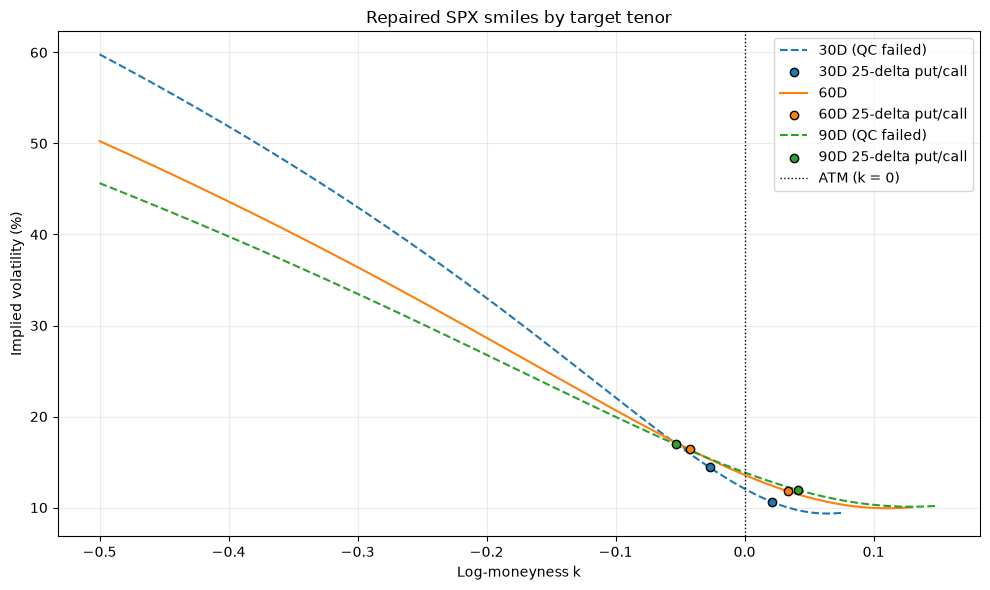

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {30: 'tab:blue', 60: 'tab:orange', 90: 'tab:green'}
for row in metrics.itertuples(index=False):
    tenor_smile = smiles.loc[smiles['target_days'].eq(row.target_days)]
    if tenor_smile.empty:
        ax.plot([], [], color=colors[row.target_days], label=f'{row.target_days}D (unavailable)')
        continue
    label = f'{row.target_days}D' if row.surface_valid else f'{row.target_days}D (QC failed)'
    ax.plot(
        tenor_smile['log_moneyness'], 100 * tenor_smile['implied_volatility'],
        color=colors[row.target_days], linestyle='-' if row.surface_valid else '--',
        label=label,
    )
    if row.rr25_valid:
        ax.scatter([row.k_25_put, row.k_25_call],
                   [100 * row.iv_25_put, 100 * row.iv_25_call],
                   color=colors[row.target_days], marker='o', edgecolor='black', zorder=3,
                   label=f'{row.target_days}D 25-delta put/call')
ax.axvline(0.0, color='black', linestyle=':', linewidth=1, label='ATM (k = 0)')
ax.set(xlabel='Log-moneyness k', ylabel='Implied volatility (%)', title='Repaired SPX smiles by target tenor')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Skew measures and quality flags

ATM IV, local ATM skew slope, and 25-delta risk reversal have separate validity flags. The ATM skew slope is $-[\sigma(0.01)-\sigma(-0.01)]/0.02$, reported in volatility points per 1% change in $k$; positive values indicate the usual downside skew. Downside risk reversal is $\sigma_{25\Delta\,put}-\sigma_{25\Delta\,call}$. We use unadjusted Black forward deltas $N(-d_1)$ and $N(d_1)$ and require a unique root on each OTM side. Each metric is missing only when its own required points or checks fail.

In [3]:
display(metrics.assign(
    quote_date=metrics['quote_date'].dt.strftime('%Y-%m-%d'),
    atm_iv_percent=100 * metrics['atm_iv'],
    atm_skew_slope_vol_points_per_1pct_k=metrics['atm_skew_slope'],
    rr25_downside_vol_points=100 * metrics['rr25_downside'],
)[['quote_date', 'target_days', 'atm_iv_percent', 'atm_skew_slope_vol_points_per_1pct_k',
   'rr25_downside_vol_points', 'k_25_put', 'k_25_call', 'atm_valid',
   'slope_valid', 'rr25_valid', 'surface_valid', 'convexity_valid',
   'failure_reason_atm', 'failure_reason_slope', 'failure_reason_rr25',
   'failure_reason_surface',
   'minimum_call_slope', 'maximum_call_slope', 'k_at_minimum_call_slope',
   'k_at_maximum_call_slope']].round(5))

assert metrics['target_days'].tolist() == [30, 60, 90]
assert metrics.loc[~metrics['atm_valid'], 'atm_iv'].isna().all()
assert metrics.loc[~metrics['slope_valid'], 'atm_skew_slope'].isna().all()
assert metrics.loc[~metrics['rr25_valid'], 'rr25_downside'].isna().all()
assert metrics.loc[metrics['atm_valid'], 'atm_iv'].gt(0).all()
assert np.isfinite(metrics.loc[metrics['slope_valid'], 'atm_skew_slope']).all()
assert np.isfinite(metrics.loc[metrics['rr25_valid'], 'rr25_downside']).all()
print('Positive ATM skew slope means IV falls as k increases.')
print('Positive downside risk reversal means 25-delta put IV exceeds 25-delta call IV.')
print('ATM IV in percent:', (100 * metrics.loc[metrics['atm_valid'], 'atm_iv']).describe().round(4).to_dict())
print('ATM skew slope in vol points per 1% k:', metrics.loc[metrics['slope_valid'], 'atm_skew_slope'].describe().round(4).to_dict())
print('25-delta downside risk reversal in vol points:', (100 * metrics.loc[metrics['rr25_valid'], 'rr25_downside']).describe().round(4).to_dict())

,quote_date,target_days,atm_iv_percent,atm_skew_slope_vol_points_per_1pct_k,rr25_downside_vol_points,k_25_put,k_25_call,atm_valid,slope_valid,rr25_valid,surface_valid,convexity_valid,failure_reason_atm,failure_reason_slope,failure_reason_rr25,failure_reason_surface,minimum_call_slope,maximum_call_slope,k_at_minimum_call_slope,k_at_maximum_call_slope
0,2025-08-29,30,12.06245,0.77258,3.77274,-0.02701,0.02103,True,True,True,False,False,,,,butterfly_convexity,-1.00000,-0.00240,-0.27000,0.07486
1,2025-08-29,60,13.58876,0.59651,4.58578,-0.04262,0.03343,True,True,True,True,True,,,,,-0.99713,-0.00057,-0.49984,0.12984
2,2025-08-29,90,13.85904,0.52441,5.01997,-0.05320,0.04167,True,True,True,False,False,,,,butterfly_convexity,-1.00000,-0.00122,-0.30500,0.14984


Positive ATM skew slope means IV falls as k increases.
Positive downside risk reversal means 25-delta put IV exceeds 25-delta call IV.
ATM IV in percent: {'count': 3.0, 'mean': 13.1701, 'std': 0.9687, 'min': 12.0624, '25%': 12.8256, '50%': 13.5888, '75%': 13.7239, 'max': 13.859}
ATM skew slope in vol points per 1% k: {'count': 3.0, 'mean': 0.6312, 'std': 0.1277, 'min': 0.5244, '25%': 0.5605, '50%': 0.5965, '75%': 0.6845, 'max': 0.7726}
25-delta downside risk reversal in vol points: {'count': 3.0, 'mean': 4.4595, 'std': 0.6331, 'min': 3.7727, '25%': 4.1793, '50%': 4.5858, '75%': 4.8029, 'max': 5.02}
